In [2]:
import pandas as pd
import numpy as np
import torch
from torch import nn
import torchvision
from torchvision import datasets
import matplotlib.pyplot as plt 
from torch.utils.data import DataLoader


##### **LOADING A in-built dataset**


In [3]:
train_data=datasets.MNIST(root="data",train=True,download=True,transform=torchvision.transforms.ToTensor(),target_transform=None)
test_data=datasets.MNIST(root="data",train=False,download=True,transform=torchvision.transforms.ToTensor(),target_transform=None)


100.0%
100.0%
100.0%
100.0%


In [4]:
len(train_data),len(test_data)

(60000, 10000)

#### train_data[0] gives Tuple: (image_tensor, label).

In [5]:
image,label=train_data[0]
image,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [6]:
class_names=train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [7]:
class_to_idx=train_data.class_to_idx
class_to_idx

{'0 - zero': 0,
 '1 - one': 1,
 '2 - two': 2,
 '3 - three': 3,
 '4 - four': 4,
 '5 - five': 5,
 '6 - six': 6,
 '7 - seven': 7,
 '8 - eight': 8,
 '9 - nine': 9}

In [8]:
train_data.targets[:11]

tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3])

In [9]:
image.shape,class_names[label]

(torch.Size([1, 28, 28]), '5 - five')

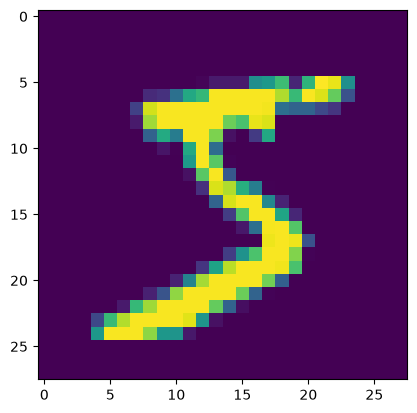

In [10]:
plt.imshow(image.squeeze())

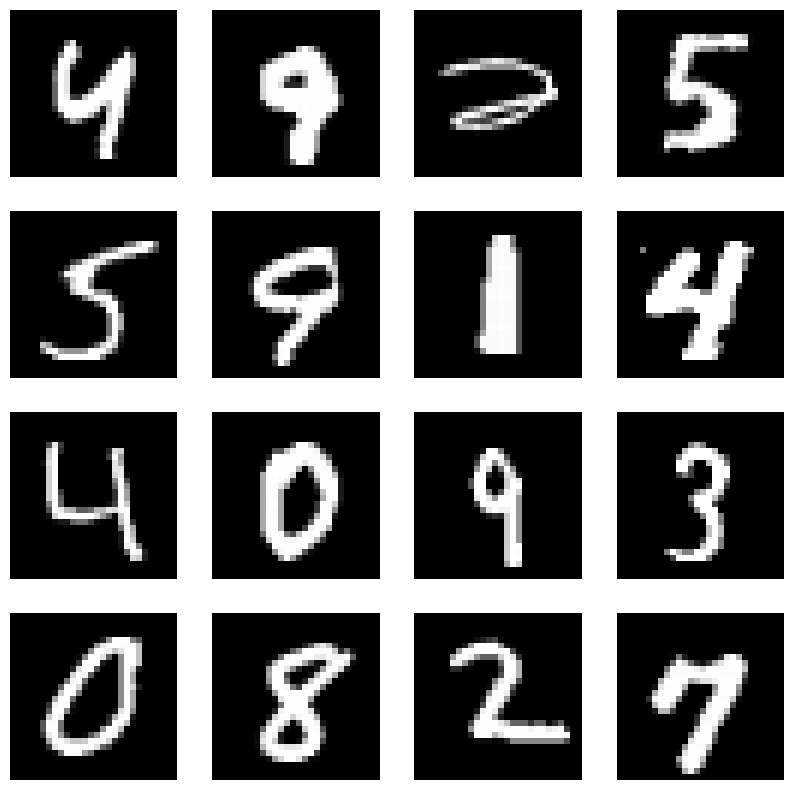

In [11]:
plot_page=plt.figure(figsize=(10,10))
rows=4
cols=4
for i in range(1,rows*cols+1):
    random_index=torch.randint(0,len(train_data),size=[1]).item()
    image,label=train_data[random_index]
    plot_page.add_subplot(rows,cols,i)
    plt.imshow(image.squeeze(),cmap="gray")
    plt.axis(False)

In [12]:
train_data,test_data

(Dataset MNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [13]:
BATCH_SIZE = 32 # Hyper parameters

train_dataloader=DataLoader(dataset=train_data,batch_size=BATCH_SIZE,shuffle=True)

test_dataloader=DataLoader(dataset=test_data,batch_size=BATCH_SIZE,shuffle=False)

train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x1e638261160>,
 <torch.utils.data.dataloader.DataLoader at 0x1e6385bfed0>)

In [14]:
print(f"Length of the training data before DataLoader:{len(train_data)}")
print(f"Length of the training data before DataLoader:{len(test_data)}")
print(f"Length of the training data after DataLoader:{len(train_dataloader)}")
print(f"Length of the training data after DataLoader:{len(test_dataloader)}")


Length of the training data before DataLoader:60000
Length of the training data before DataLoader:10000
Length of the training data after DataLoader:1875
Length of the training data after DataLoader:313


In [15]:
image,label=train_data[0]
image.shape

torch.Size([1, 28, 28])

In [16]:
images,labels=next(iter(train_dataloader))
images.shape,labels.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

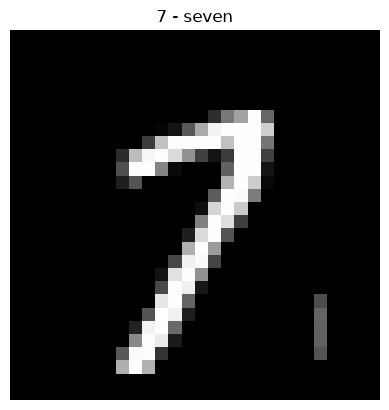

In [17]:
random_idx=torch.randint(0,len(images),size=[1]).item()
img,label=images[random_idx],labels[random_idx]
plt.imshow(img.squeeze(),cmap="gray")
plt.title(class_names[label])
plt.axis(False)

In [ ]:


labels[:11]

tensor([1, 9, 8, 0, 1, 5, 1, 2, 1, 7, 3])